# Heart Disease Modeling Project
### Data Science Fundamentals with Python 

This notebook uses the **UCI Heart Disease dataset to do, classification, regression, dimensionality reduction, and clustering techniques on real clinical data.

**Workflow of this notebook:**
1. Exploratory data analysis (EDA) and preprocessing
2. Heart disease prediction (classification)
3. Cholesterol level prediction (regression)
4. Correlation analysis
5. Principal component analysis (PCA)
6. Patient clustering (K-means)
7. Final conclusions

## 0. Imports & Plot Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Consistent, professional-looking plots throughout the notebook ;;;
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"

np.random.seed(42)
RANDOM_STATE = 42

## 1. Dataset Reference

We use the **Cleveland** dataset from the UCI Heart Disease repository:
 303 instances, 13 clinical features, and one numerical target (`num`) representing presence/absence of heart disease.

![image.png](attachment:image.png)
We load the dataset using the code provided by the UCI repository, with a local copy as a fallback if the online source is unavailable.

In [2]:
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

try:
    df = pd.read_csv(uci_url, names=column_names)
except Exception as e:
    print("Could not reach the UCI website directly, using local copy instead:", e)
    df = pd.read_csv("processed.cleveland.data", names=column_names)

df.head()

Could not reach the UCI website directly, using local copy instead: HTTP Error 403: Forbidden


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Exploratory Data Analysis & Data Preprocessing

### 2.1 First look at the data

In [3]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFeature names: {list(df.columns)}")
df.head()

Dataset shape: 303 rows, 14 columns

Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


What we learned: The dataset has 303 patient records and 14 columns (13 features and the num target). Most columns are numeric, but ca and thal contain missing values (?) that need cleaning. The features also have different value ranges, so we'll scale them before training the models.

### 2.2 Handling missing values

In [6]:
df.replace('?', np.nan, inplace=True)
df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)

missing_counts = df.isnull().sum()
missing_counts

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

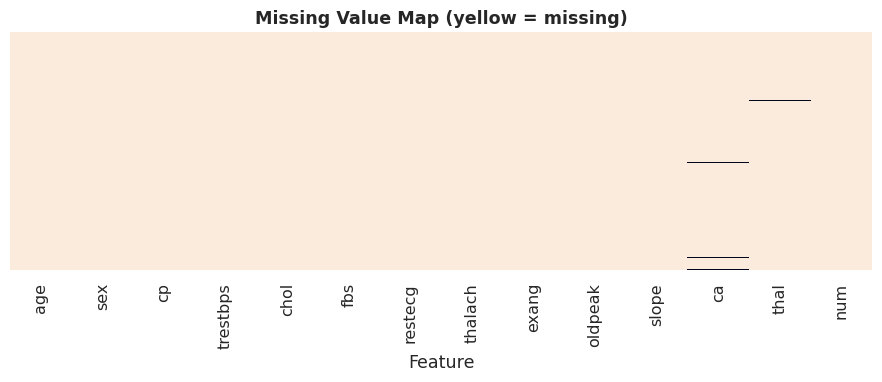

In [7]:
# Visualizing where the missing values are located
plt.figure(figsize=(9, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="rocket_r", yticklabels=False)
plt.title("Missing Value Map (yellow = missing)")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

> **What we learned:** Only `ca` (4) and `thal` (2) have missing values. Since there are very few missing entries, using median imputation is a simple and safe choice.


> We fill the missing values using the median of each column, as required by the project.


In [8]:
df.fillna(df.median(), inplace=True)
assert df.isnull().sum().sum() == 0, "There should be no missing values left."
print("All missing values imputed successfully.")

All missing values imputed successfully.


### 2.3 Converting the target to binary

In [9]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

target_counts = df['num'].value_counts()
target_pct = df['num'].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(1))

num
0    164
1    139
Name: count, dtype: int64
num
0    54.1
1    45.9
Name: proportion, dtype: float64


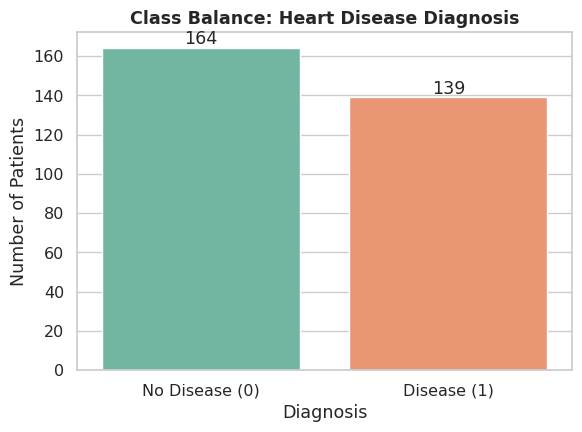

In [10]:
# Class balance visualization
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x='num', data=df, hue='num', legend=False, palette="Set2")
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'])
for container in ax.containers:
    ax.bar_label(container)
plt.title("Class Balance: Heart Disease Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

> **What we learned:** The dataset is fairly balanced, with about 54% of patients having no heart disease and 46% having heart disease. This means we can train the models without handling class imbalance separately.


### 2.4 Distributions of numerical features

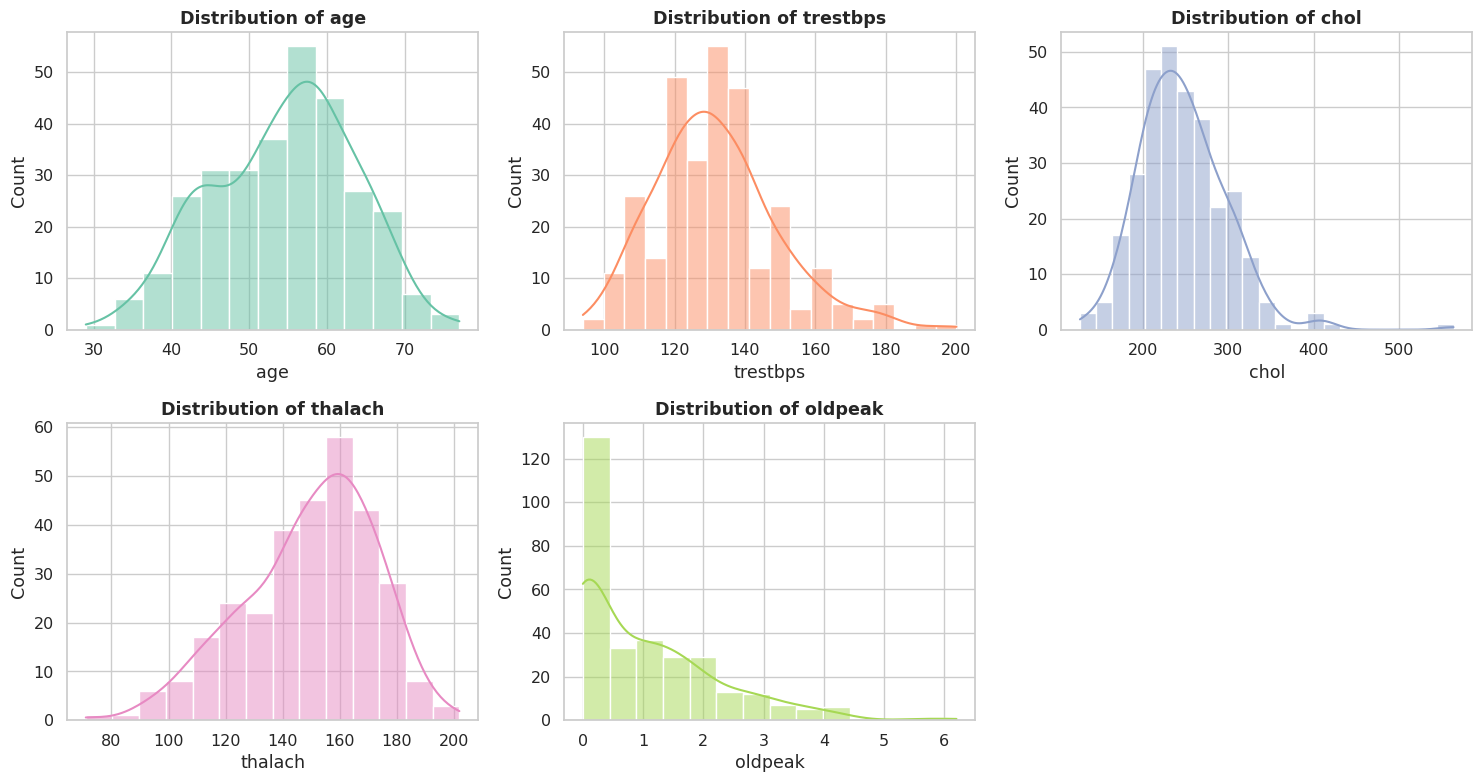

In [11]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("Set2")[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
axes[-1].axis('off')  # unused subplot
plt.tight_layout()
plt.show()

> **What we learned:** Most features follow a normal distribution. `chol` and `oldpeak` are slightly right-skewed, with a few high values that may be outliers.


### 2.5 Boxplots — checking for outliers

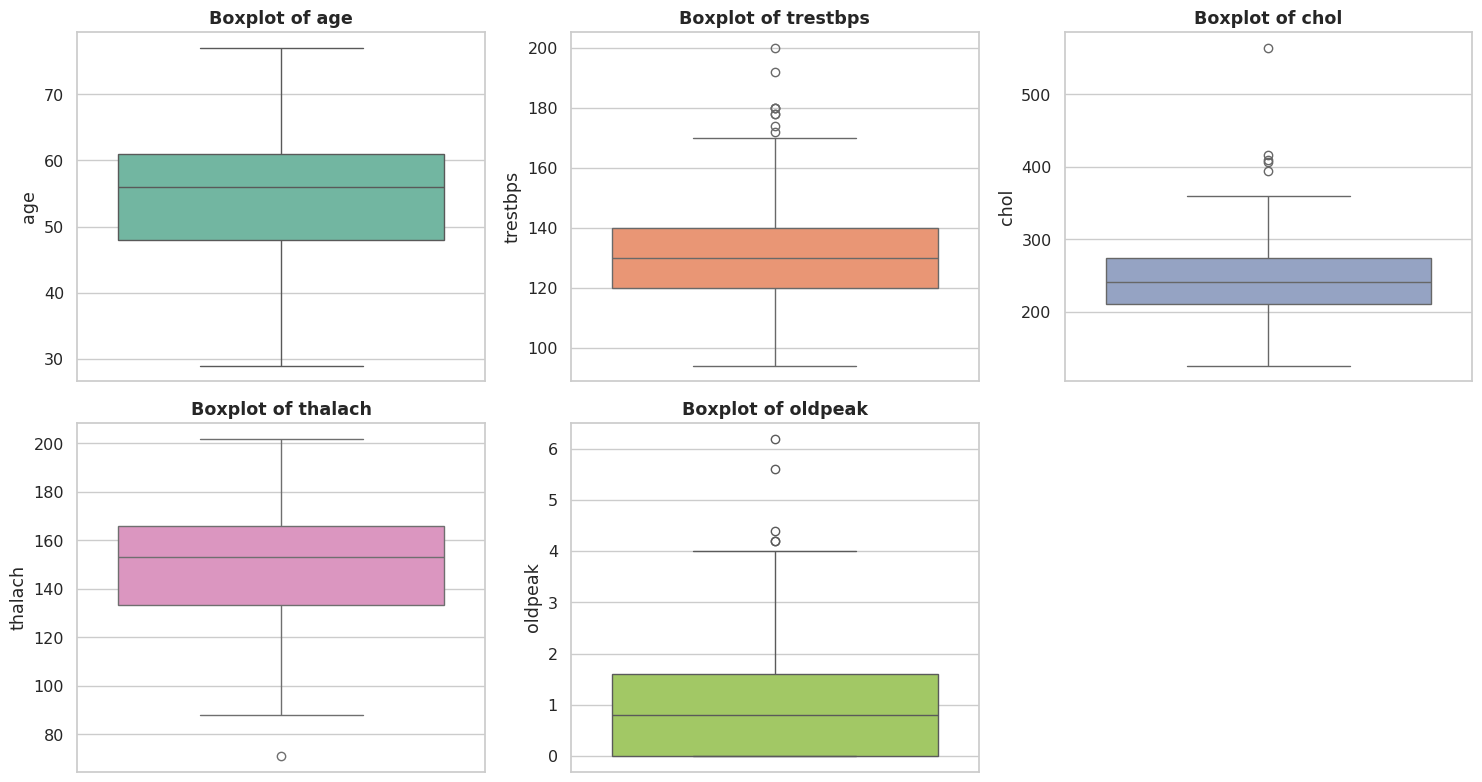

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette("Set2")[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

> **What we learned:** A few outliers are present in `chol`, `trestbps`, and `oldpeak`, but they appear to be valid values. We keep them since they are unlikely to affect the models significantly.


### 2.6 Pairwise relationships

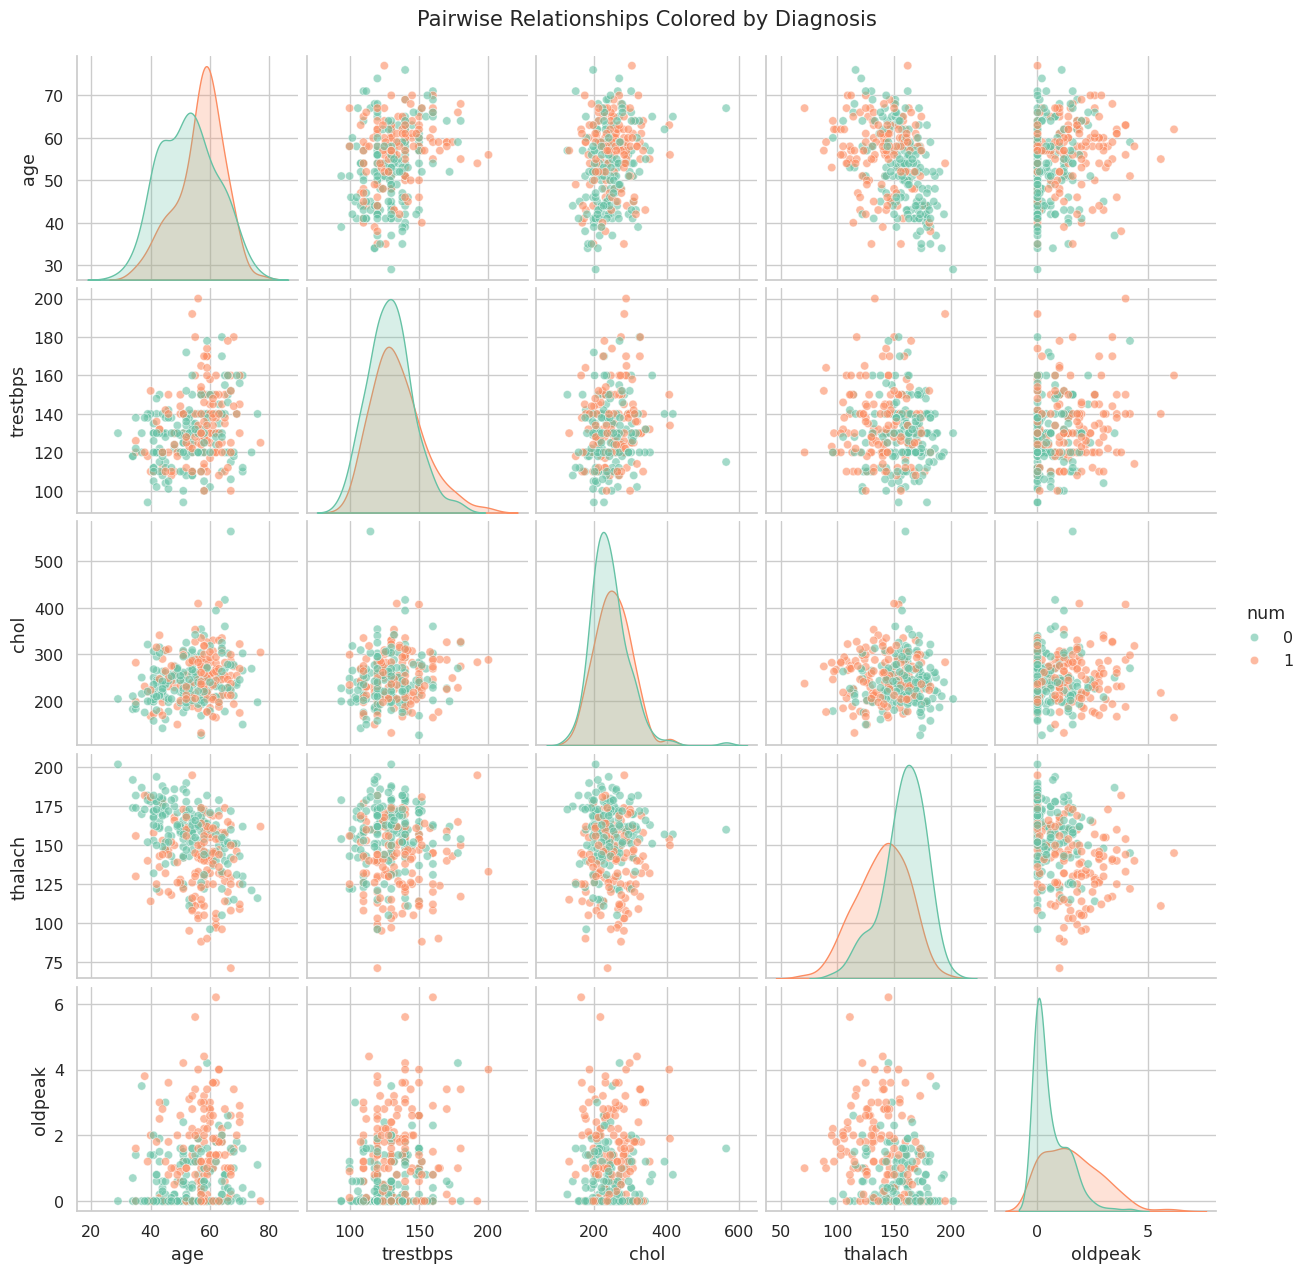

In [13]:
pair_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'num']
sns.pairplot(df[pair_cols], hue='num', palette="Set2", diag_kind="kde", plot_kws={'alpha': 0.6})
plt.suptitle("Pairwise Relationships Colored by Diagnosis", y=1.02)
plt.show()

> **What we learned:** `thalach` and `oldpeak` show the biggest difference between healthy and diseased patients. `age`, `trestbps`, and `chol` overlap a lot, making them weaker predictors on their own.


### 2.7 Normalizing the features

> **Note:** To avoid data leakage, we scale the data only after splitting it into training and testing sets. The original dataset remains unchanged, and scaling is done separately for each task.


## 3. Heart Disease Prediction (Classification)

> We train Logistic Regression and Random Forest models to predict heart disease. The data is split first, and the scaler is fitted only on the training set.


In [14]:
# 1. Split first
X = df.drop(columns=['num'])
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2. Fit the scaler ONLY on the training data, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]} patients | Test set: {X_test_scaled.shape[0]} patients")

Train set: 242 patients | Test set: 61 patients


In [15]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

### 3.1 Classification reports

In [16]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log, target_names=['No Disease', 'Disease']))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

=== Random Forest ===
              precision    recall  f1-score   support

  No Disease       0.97      0.85      0.90        33
     Disease       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



### 3.2 Confusion matrices

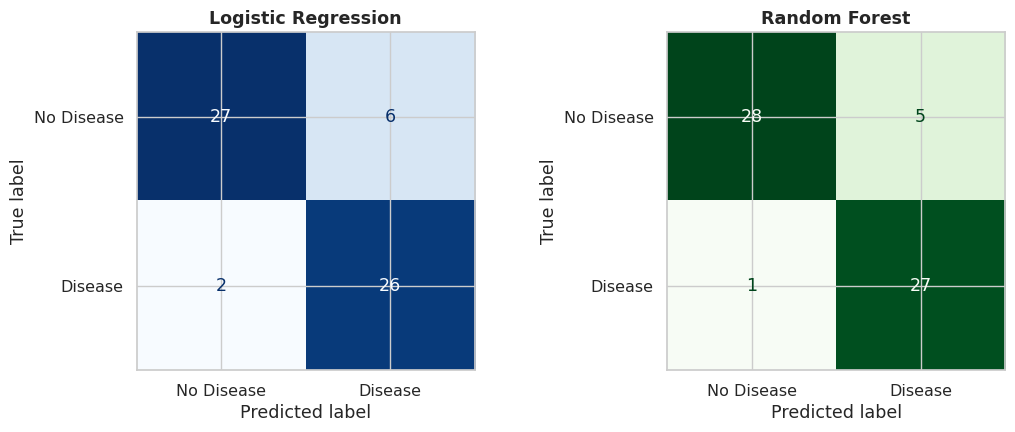

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log),
                        display_labels=['No Disease', 'Disease']).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                        display_labels=['No Disease', 'Disease']).plot(ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

### 3.3 ROC Curves

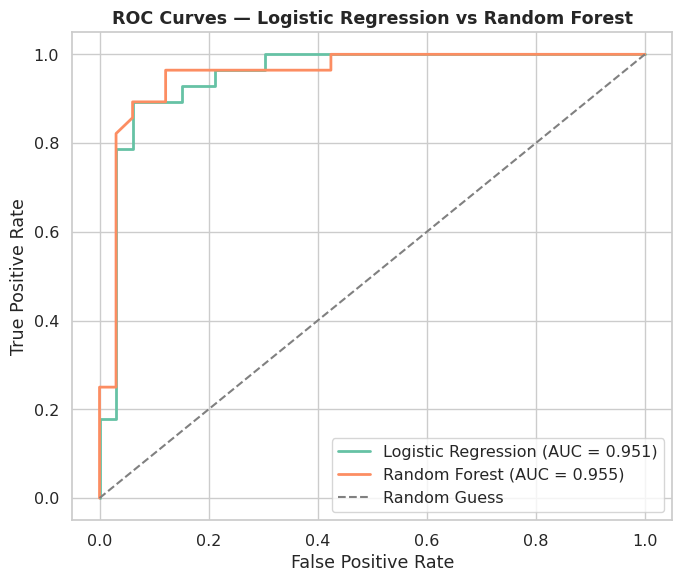

In [18]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Logistic Regression vs Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 3.4 Model comparison table

In [19]:
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

comparison_df = pd.DataFrame([
    get_metrics("Logistic Regression", y_test, y_pred_log, y_proba_log),
    get_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf),
]).set_index("Model").round(3)

comparison_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.869,0.812,0.929,0.867,0.951
Random Forest,0.902,0.844,0.964,0.900,0.955


> **Model comparison:** Both models performed well, but **Random Forest** gave slightly better results across all metrics. It handles non-linear patterns and is more robust to outliers, while **Logistic Regression** is simpler, faster, and easier to interpret. Since the dataset is small, the difference in performance is only slight.


## 4. Feature Importance (Random Forest)

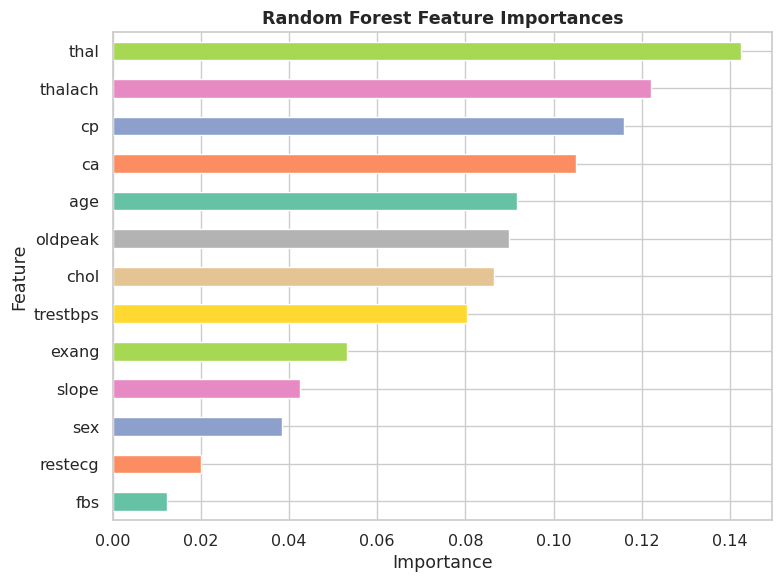

thal        0.142406
thalach     0.122051
cp          0.115927
ca          0.105126
age         0.091680
oldpeak     0.089759
chol        0.086475
trestbps    0.080274
exang       0.053057
slope       0.042552
sex         0.038343
restecg     0.020006
fbs         0.012343
dtype: float64

In [20]:
feature_importance = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh', color=sns.color_palette("Set2", len(feature_importance)))
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

feature_importance.sort_values(ascending=False)

> **What we learned:** `thal`, `thalach`, `cp`, and `ca` are the most important features for predicting heart disease. In contrast, `fbs`, `restecg`, and `sex` have the least impact on the model.



## 5. Cholesterol Level Prediction (Regression)
\> We use multiple linear regression to predict cholesterol (`chol`). The data is split first, and only the training data is used to fit the scaler.


In [21]:
X_reg = df.drop(columns=['chol', 'num'])
y_reg = df['chol']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_scaler = StandardScaler()
X_train_r_scaled = reg_scaler.fit_transform(X_train_r)
X_test_r_scaled = reg_scaler.transform(X_test_r)

lin_reg = LinearRegression()
lin_reg.fit(X_train_r_scaled, y_train_r)
y_pred_r = lin_reg.predict(X_test_r_scaled)

### 5.1 Regression metrics

In [22]:
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"MAE  : {mae:.2f} mg/dl")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} mg/dl")
print(f"R^2  : {r2:.3f}")

MAE  : 41.17 mg/dl
MSE  : 3506.01
RMSE : 59.21 mg/dl
R^2  : 0.134


### 5.2 Actual vs. Predicted, and residuals

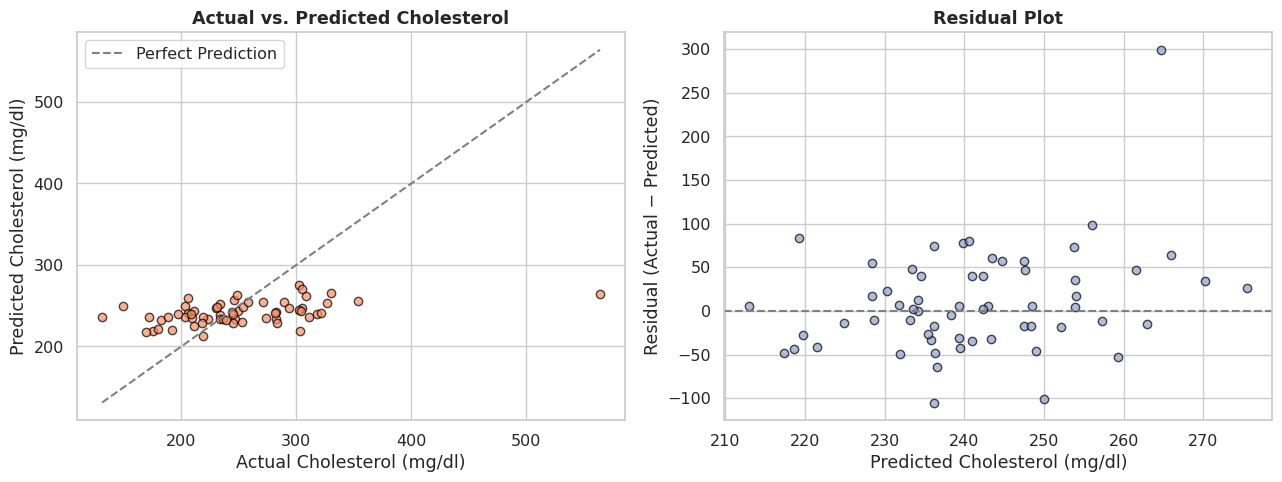

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test_r, y_pred_r, alpha=0.7, edgecolor='k', color=sns.color_palette("Set2")[1])
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
axes[0].plot(lims, lims, linestyle='--', color='gray', label="Perfect Prediction")
axes[0].set_xlabel("Actual Cholesterol (mg/dl)")
axes[0].set_ylabel("Predicted Cholesterol (mg/dl)")
axes[0].set_title("Actual vs. Predicted Cholesterol")
axes[0].legend()

# Residuals
residuals = y_test_r - y_pred_r
axes[1].scatter(y_pred_r, residuals, alpha=0.7, edgecolor='k', color=sns.color_palette("Set2")[2])
axes[1].axhline(0, linestyle='--', color='gray')
axes[1].set_xlabel("Predicted Cholesterol (mg/dl)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

> **What we learned:** The model predicts cholesterol poorly, with a low R² and high error. This suggests that the available features are not enough to accurately predict cholesterol levels.


## 6. Correlation Analysis

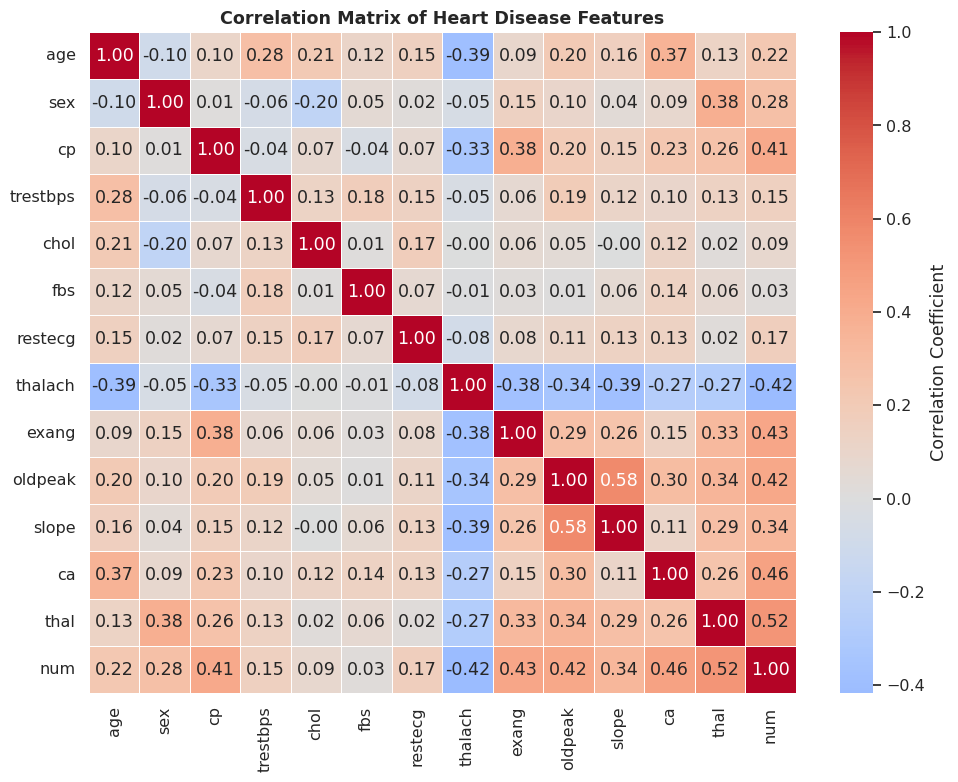

In [24]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation Coefficient"})
plt.title("Correlation Matrix of Heart Disease Features")
plt.tight_layout()
plt.show()

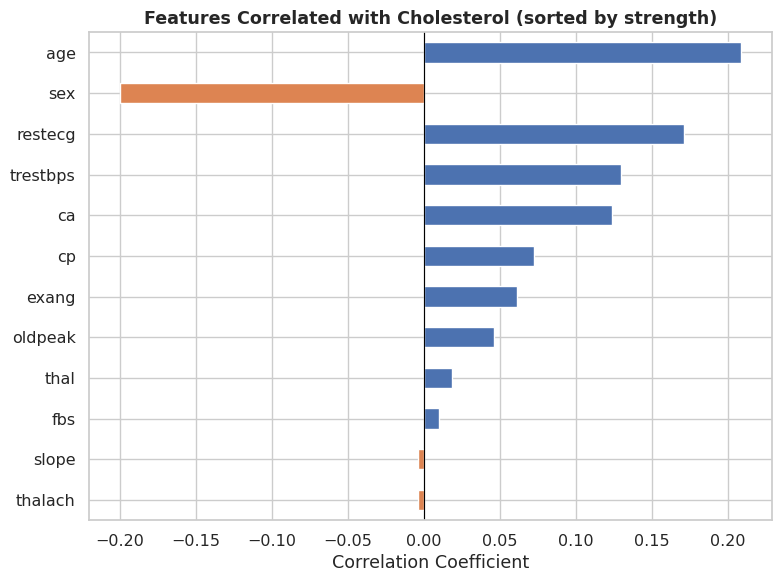

age         0.209
sex        -0.200
restecg     0.171
trestbps    0.130
ca          0.124
cp          0.072
exang       0.061
oldpeak     0.047
thal        0.018
fbs         0.010
slope      -0.004
thalach    -0.003
Name: chol, dtype: float64

In [25]:
# Top features most correlated with cholesterol (excluding chol itself and the diagnosis target)
chol_corr = corr_matrix['chol'].drop(['chol', 'num']).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
chol_corr.plot(kind='barh', color=['#4C72B0' if v > 0 else '#DD8452' for v in chol_corr.values])
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Features Correlated with Cholesterol (sorted by strength)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

chol_corr.round(3)

Got it. I'll **simplify the language without removing important information**.

Your paragraph becomes:

> **What we learned:** `age` and `restecg` have the strongest positive correlation with cholesterol, while `sex` has the strongest negative correlation. Features like `thalach`, `slope`, `fbs`, and `thal` show little to no correlation. Overall, no feature is strongly related to cholesterol, which explains why the regression model has a low R² and poor prediction performance.


## 7. Principal Component Analysis
 **Why PCA?** PCA reduces the number of features by combining related ones while keeping most of the important information. This makes the data easier to visualize and improves clustering.

**Why 95% variance?** Keeping 95% of the variance preserves most of the useful information while removing a small amount of noise.

 Since PCA and K-Means are **unsupervised** methods, we fit the scaler and PCA on the full dataset. Unlike classification and regression, there is no train-test split because no target variable is being predicted.


In [26]:
# Fit a scaler on the full feature set (unsupervised context — no leakage concern here)
full_scaler = StandardScaler()
X_scaled_full = full_scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_full)

print(f"Original number of features : {X.shape[1]}")
print(f"Components retained (95% variance): {pca.n_components_}")
print(f"Reduced dataset shape        : {X_pca.shape}")

Original number of features : 13
Components retained (95% variance): 12
Reduced dataset shape        : (303, 12)


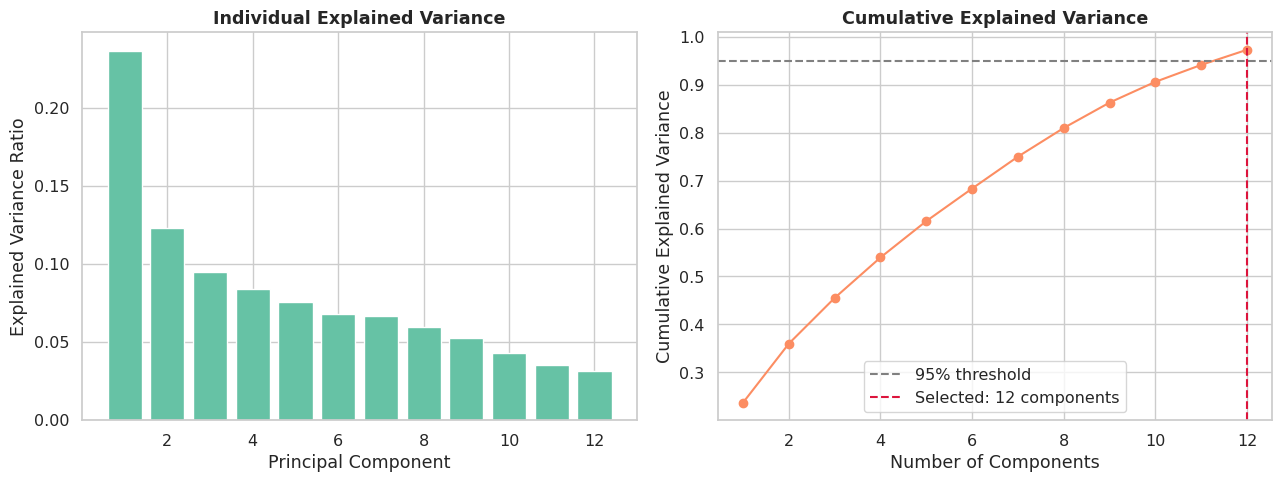

In [27]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_selected = pca.n_components_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained) + 1), explained, color=sns.color_palette("Set2")[0])
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Individual Explained Variance")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o', color=sns.color_palette("Set2")[1])
axes[1].axhline(0.95, color='gray', linestyle='--', label="95% threshold")
axes[1].axvline(n_selected, color='crimson', linestyle='--', label=f"Selected: {n_selected} components")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

**What we learned:** It takes **12 of the original 13 features'** worth of components to reach 95% of the variance — the cumulative variance curve rises almost linearly rather than flattening out early. This tells us the 13 clinical features are largely **independent of one another** (little redundancy), so PCA only achieves a modest compression (13 → 12 dimensions) here, even though it's still useful for feeding a distance-based algorithm like K-Means in the next section.

## 8. Grouping Patients based on Health Profiles (K-Means Clustering)

Using the PCA-reduced dataset, we apply K-Means clustering to group patients by health profile. We use the **Elbow method** and **Silhouette score** to choose the optimal number of clusters.

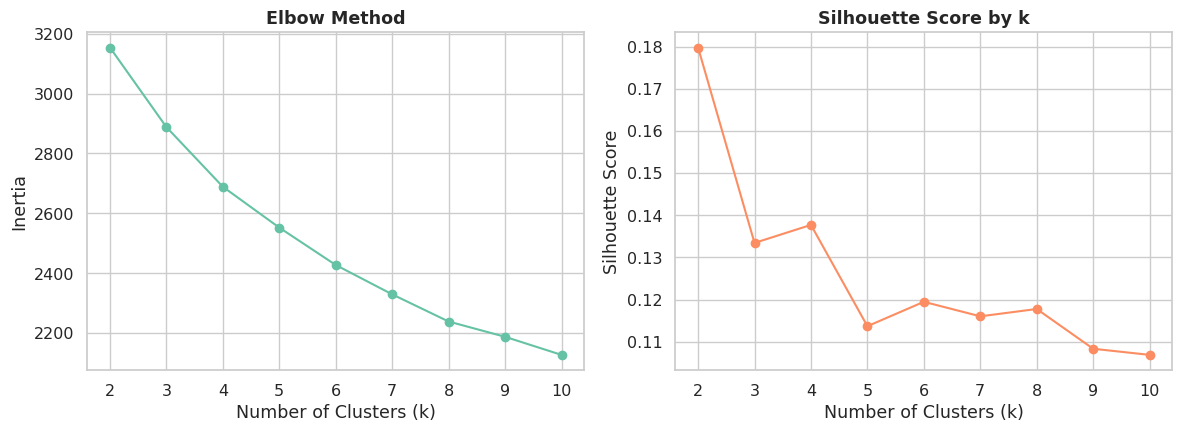

Best k by silhouette score: 2


In [28]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(k_range), inertias, marker='o', color=sns.color_palette("Set2")[0])
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette_scores, marker='o', color=sns.color_palette("Set2")[1])
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"Best k by silhouette score: {best_k}")

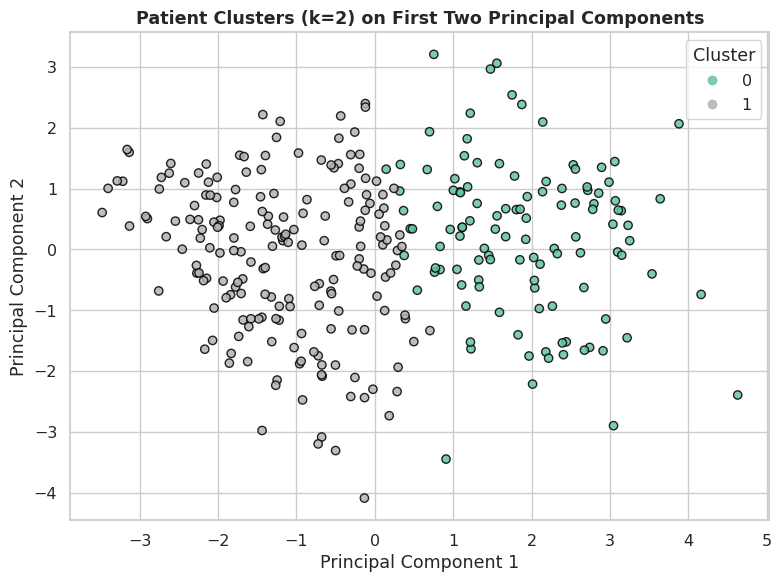

In [29]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='Set2', alpha=0.85, edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"Patient Clusters (k={best_k}) on First Two Principal Components")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

### 8.1 Interpreting the clusters

In [30]:
df_clusters = df.copy()
df_clusters['Cluster'] = cluster_labels

cluster_profile = df_clusters.groupby('Cluster').mean().T
print("Patients per cluster:")
print(df_clusters['Cluster'].value_counts())
cluster_profile.round(2)

Patients per cluster:
Cluster
1    189
0    114
Name: count, dtype: int64


Cluster,0,1
age,58.23,52.15
sex,0.82,0.60
cp,3.77,2.79
trestbps,134.96,129.71
chol,254.67,241.88
fbs,0.19,0.12
restecg,1.22,0.85
thalach,132.95,159.66
exang,0.68,0.12
oldpeak,1.87,0.54


**Cluster summary** (based on the group means above):

**Cluster 0. Higher-risk profile**

- People in this group are older, around 58 years old and most of them are men

- They have blood pressure, higher cholesterol and more problems with their heart when they are resting

- When they exercise they have lower heart rates and are more likely to have chest pain and other heart problems

- More of the blood vessels in their heart are affected and they have more abnormal test results

- About 89 percent of the people in this group have heart disease

**Cluster 1. Lower-risk profile**

- People in this group are younger, around 52 years old

- They have lower blood pressure, lower cholesterol and higher heart rates when they exercise

- They are less likely to have chest pain or other heart problems when they exercise

- Fewer of the blood vessels in their heart are affected and most of their test results are normal

- Only about 20 percent of the people in this group have heart disease

**Interpretation:** What is interesting is that we found these two groups without using the diagnosis of heart disease.. The two groups we found are very similar to the actual number of people with heart disease. Cluster 0 is like a group of people with a risk of heart problems and Cluster 1 is like a group of people with a lower risk of heart problems. This tells us that the things we are measuring like blood pressure and cholesterol are really important for understanding who's, at risk of heart disease.

## 9. Final Conclusion

**Dataset overview:** We used the UCI Cleveland Heart Disease dataset with 303 patients and 13 clinical features. Missing values were filled using median imputation, and the diagnosis was converted into a binary target.

**EDA findings:** The dataset is fairly balanced between patients with and without heart disease. `thalach` and `oldpeak` showed the biggest difference between the two groups, while `age`, `trestbps`, and `chol` overlapped a lot. A few outliers were found in `chol`, `trestbps`, and `oldpeak`, but they were kept since they are clinically valid.

**Best classification model:** **Random Forest** performed slightly better than Logistic Regression in accuracy, precision, recall, F1-score, and ROC-AUC (AUC ≈ 0.955 vs. 0.951). This is because it can capture non-linear relationships between features like `thal`, `cp`, and `ca`, which were also the most important features.

**Regression performance:** Predicting cholesterol from the other clinical features was **difficult** (R² ≈ 0.13). This is expected because cholesterol depends on factors like diet, genetics, and lifestyle, which are not included in this dataset. The strongest correlations were with `age`, `sex`, and `restecg`, but all were weak.

**PCA results:** To retain 95% of the data's variance, PCA needed 12 out of the original 13 components. This suggests that most features contain unique information and there is little redundancy.

**Clustering insights:** K-Means (k=2) grouped the patients into two clear clusters. One cluster had older patients with poorer heart health and about 89% disease prevalence, while the other had younger patients with healthier clinical values and about 20% disease prevalence. This was achieved without using the diagnosis labels.

**Overall learning:** This project demonstrates a complete machine learning workflow, including data cleaning, EDA, classification, regression, PCA, and clustering. Each method provided useful insights into the factors related to heart disease.